In [1]:
!pip install -q kaggle pandas numpy scikit-learn xgboost openpyxl

In [2]:
import os
import re
import json
import zipfile
import warnings
import numpy as np
import pandas as pd

from google.colab import files

warnings.filterwarnings("ignore")

print("Environnement prêt.")

Environnement prêt.


COnfig KAGGLE et récpération Dataset

In [3]:
import getpass, os, json

# SECURITE : ne jamais coller ta clé API Kaggle en clair dans le notebook.
# Ce fichier peut être partagé/uploadé (comme tu viens de le faire) et la clé
# serait alors compromise. Si tu avais déjà mis ta vraie clé ici, régénère-en
# une nouvelle sur Kaggle (Account > API > "Create New Token") pour invalider
# l'ancienne, puis renseigne les nouveaux identifiants ci-dessous.

kaggle_username = input("Ton username Kaggle (sans espace, ex: liantsoah) : ").strip()
kaggle_key = getpass.getpass("Ta clé API Kaggle (saisie masquée) : ").strip()

os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump({"username": kaggle_username, "key": kaggle_key}, f)

!chmod 600 /root/.kaggle/kaggle.json


Ton username Kaggle (sans espace, ex: liantsoah) : Liantsoa Harimisa
Ta clé API Kaggle (saisie masquée) : ··········


In [4]:
!pip install -q kaggle
!kaggle datasets download -d shanimmahir/studies-career-recommendation-dataset
!unzip -o studies-career-recommendation-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/shanimmahir/studies-career-recommendation-dataset
License(s): apache-2.0
100% 184k/184k [00:00<00:00, 710kB/s]

Archive:  studies-career-recommendation-dataset.zip
  inflating: student-scores-6k.csv   


In [5]:
!ls -la

total 868
drwxr-xr-x 1 root root   4096 Aug 27 07:02 .
drwxr-xr-x 1 root root   4096 Aug 27 06:55 ..
drwxr-xr-x 4 root root   4096 Aug 24 13:21 .config
drwxr-xr-x 1 root root   4096 Aug 24 13:21 sample_data
-rw-r--r-- 1 root root 680347 Jul 25  2024 student-scores-6k.csv
-rw-r--r-- 1 root root 188176 Jul 25  2024 studies-career-recommendation-dataset.zip


Lecture dataset

In [6]:
import pandas as pd

df = pd.read_csv("student-scores-6k.csv")

print(df.shape)
print(df.columns.tolist())
df.info()

df.head()

(6000, 17)
['id', 'first_name', 'last_name', 'email', 'gender', 'part_time_job', 'absence_days', 'extracurricular_activities', 'weekly_self_study_hours', 'career_aspiration', 'math_score', 'history_score', 'physics_score', 'chemistry_score', 'biology_score', 'english_score', 'geography_score']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   id                          6000 non-null   int64 
 1   first_name                  6000 non-null   object
 2   last_name                   6000 non-null   object
 3   email                       6000 non-null   object
 4   gender                      6000 non-null   object
 5   part_time_job               6000 non-null   bool  
 6   absence_days                6000 non-null   int64 
 7   extracurricular_activities  6000 non-null   bool  
 8   weekly_self_study_hours     6000 

,id,first_name,last_name,email,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,1,Paul,Casey,paul.casey.1@gslingacademy.com,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87
1,2,Danielle,Sandoval,danielle.sandoval.2@gslingacademy.com,female,False,2,False,47,Doctor,90,86,96,100,90,88,90
2,3,Tina,Andrews,tina.andrews.3@gslingacademy.com,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94
3,4,Tara,Clark,tara.clark.4@gslingacademy.com,female,False,5,False,3,Artist,71,74,88,80,89,63,86
4,5,Anthony,Campos,anthony.campos.5@gslingacademy.com,male,False,5,False,10,Social Network Studies,84,77,65,65,80,74,76


In [7]:
print(df["career_aspiration"].nunique())
print(df["career_aspiration"].value_counts())

17
career_aspiration
Software Engineer         945
Business Owner            927
Social Network Studies    669
Banker                    507
Lawyer                    414
Accountant                378
Doctor                    357
Real Estate Developer     249
Stock Investor            219
Construction Engineer     204
Artist                    201
Game Developer            189
Government Officer        183
Teacher                   177
Designer                  168
Scientist                 117
Writer                     96
Name: count, dtype: int64


In [8]:
score_cols = [
    "math_score", "history_score", "physics_score",
    "chemistry_score", "biology_score", "english_score", "geography_score"
]

df_clean = df[score_cols + ["career_aspiration"]].copy()

print(df_clean.shape)
df_clean.head()

(6000, 8)


,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score,career_aspiration
0,73,81,93,97,63,80,87,Lawyer
1,90,86,96,100,90,88,90,Doctor
2,81,97,95,96,65,77,94,Government Officer
3,71,74,88,80,89,63,86,Artist
4,84,77,65,65,80,74,76,Social Network Studies


In [9]:
print(df_clean.isnull().sum())

math_score           0
history_score        0
physics_score        0
chemistry_score      0
biology_score        0
english_score        0
geography_score      0
career_aspiration    0
dtype: int64


Encoder la cible et training

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_clean["career_encoded"] = le.fit_transform(df_clean["career_aspiration"])

# Pour se rappeler quel chiffre correspond à quelle carrière
list(enumerate(le.classes_))

[(0, 'Accountant'),
 (1, 'Artist'),
 (2, 'Banker'),
 (3, 'Business Owner'),
 (4, 'Construction Engineer'),
 (5, 'Designer'),
 (6, 'Doctor'),
 (7, 'Game Developer'),
 (8, 'Government Officer'),
 (9, 'Lawyer'),
 (10, 'Real Estate Developer'),
 (11, 'Scientist'),
 (12, 'Social Network Studies'),
 (13, 'Software Engineer'),
 (14, 'Stock Investor'),
 (15, 'Teacher'),
 (16, 'Writer')]

In [11]:
from sklearn.model_selection import train_test_split

score_cols = [
    "math_score", "history_score", "physics_score",
    "chemistry_score", "biology_score", "english_score", "geography_score"
]

X = df_clean[score_cols]
y = df_clean["career_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(4800, 7) (1200, 7)


In [12]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

EValuation

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le.classes_))

                        precision    recall  f1-score   support

            Accountant       1.00      0.92      0.96        76
                Artist       1.00      1.00      1.00        40
                Banker       0.97      0.97      0.97       101
        Business Owner       0.98      1.00      0.99       185
 Construction Engineer       1.00      1.00      1.00        41
              Designer       1.00      0.91      0.95        34
                Doctor       0.96      1.00      0.98        71
        Game Developer       1.00      1.00      1.00        38
    Government Officer       1.00      0.92      0.96        37
                Lawyer       0.97      1.00      0.98        83
 Real Estate Developer       1.00      0.94      0.97        50
             Scientist       1.00      1.00      1.00        23
Social Network Studies       0.98      0.98      0.98       134
     Software Engineer       0.94      1.00      0.97       189
        Stock Investor       1.00      

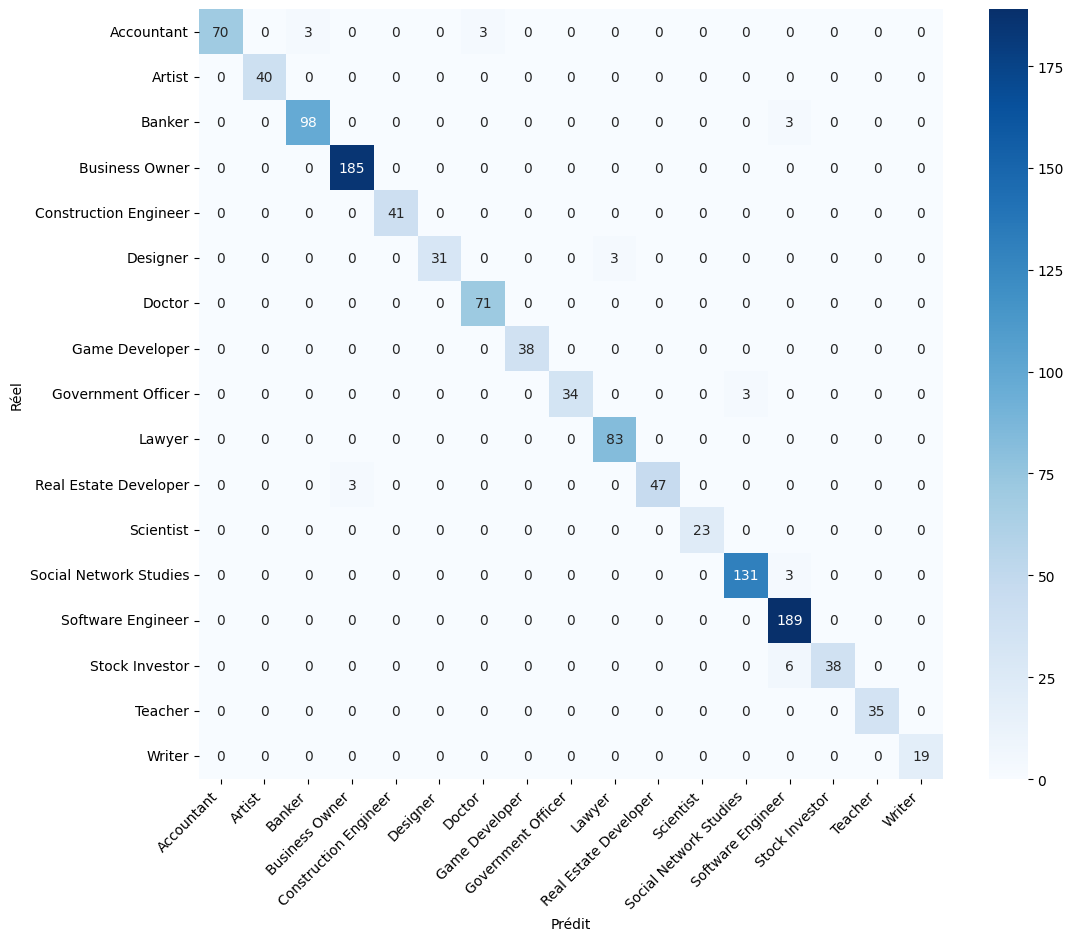

In [14]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_, cmap="Blues")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.xticks(rotation=45, ha="right")
plt.show()

In [15]:
def predire_carriere_top_n(math, history, physics, chemistry, biology, english, geography, n=3):
    notes = pd.DataFrame([{
        "math_score": math,
        "history_score": history,
        "physics_score": physics,
        "chemistry_score": chemistry,
        "biology_score": biology,
        "english_score": english,
        "geography_score": geography
    }])

    probas = model.predict_proba(notes)[0]
    resultats = pd.Series(probas, index=le.classes_).sort_values(ascending=False)
    return resultats.head(n)

# Exemple
top = predire_carriere_top_n(
    math=90, history=40, physics=85,
    chemistry=70, biology=50, english=60, geography=35,
    n=5
)
print(top)

Business Owner           0.890000
Accountant               0.070000
Software Engineer        0.016667
Game Developer           0.006667
Construction Engineer    0.006667
dtype: float64


In [16]:
!pip install -qU langchain-google-genai pydantic

SYSTEM_PROMPT = """Tu extrais les notes scolaires d'un texte libre écrit par un élève, pour les matières :
mathématiques, histoire, physique, chimie, biologie/SVT, anglais, géographie.

Règles strictes :
- N'invente jamais une note pour une matière non mentionnée : laisse-la à null.
- Une note explicite ("j'ai eu 18 en maths") est extraite telle quelle.
- Une appréciation de performance ("doué en chimie", "nul en anglais", "toujours 20 en SVT")
  est convertie en estimation raisonnable sur le même barème (ex: "doué" ~16-18/20, "nul" ~5-8/20).
- Une simple préférence ("j'adore le SVT", "je n'aime pas l'histoire") n'indique PAS une performance :
  ne l'utilise jamais seule pour déduire une note.
- Si un chiffre est donné juste après plusieurs matières citées ensemble sans note individuelle
  ("chimie et SVT, toujours 20"), applique-le à toutes les matières citées juste avant,
  uniquement si le contexte le justifie clairement.
- Détecte le barème utilisé (20, 10, ou 100) et renseigne-le dans "bareme".

Utilise l'outil extraire_notes_eleve pour renvoyer le résultat structuré."""

extraction_tool = {
    "name": "extraire_notes_eleve",
    "description": "Extrait les notes scolaires mentionnées dans un texte libre, matière par matière, et détecte le barème utilisé.",
    "input_schema": {
        "type": "object",
        "properties": {
            "math_score": {"type": ["number", "null"]},
            "history_score": {"type": ["number", "null"]},
            "physics_score": {"type": ["number", "null"]},
            "chemistry_score": {"type": ["number", "null"]},
            "biology_score": {"type": ["number", "null"]},
            "english_score": {"type": ["number", "null"]},
            "geography_score": {"type": ["number", "null"]},
            "bareme": {
                "type": "integer",
                "description": "Barème sur lequel les notes sont exprimées : 20, 10, ou 100."
            }
        },
        "required": ["bareme"]
    }
}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.0/570.0 kB 9.5 MB/s eta 0:00:00


In [ ]:
"""import re

# Mapping synonymes -> colonnes du dataset (comparé sur texte.lower(), donc
# tous les mots-clés doivent être en minuscules ici)
synonymes = {
    "math_score": ["mathématiques", "maths", "math"],
    "physics_score": ["physique", "phys"],
    "chemistry_score": ["chimie", "chim"],
    "biology_score": ["biologie", "bio", "svt"],
    "history_score": ["histoire", "hist"],
    "geography_score": ["géographie", "géo", "geo"],
    "english_score": ["anglais", "english", "ang"],
}

def extraire_notes(texte):
    texte = texte.lower()
    notes = {}
    for colonne, mots_cles in synonymes.items():
        for mot in mots_cles:
            mot_echap = re.escape(mot)
            # cherche "maths: 15", "maths 15", "15 en maths"
            pattern = rf"{mot_echap}[^\d]{{0,5}}(\d{{1,3}})|(\d{{1,3}})[^\d]{{0,5}}{mot_echap}"
            match = re.search(pattern, texte)
            if match:
                valeur = match.group(1) or match.group(2)
                notes[colonne] = float(valeur)
                break
    return notes

# Exemple
texte_user = "J'ai eu 16 en maths, 8 en physique et 14 en anglais"
notes_extraites = extraire_notes(texte_user)
print(notes_extraites)
# {'math_score': 16.0, 'physics_score': 8.0, 'english_score': 14.0}"""


{'math_score': 16.0, 'physics_score': 8.0, 'english_score': 14.0}


In [17]:
import re

# Mapping synonymes -> colonnes du dataset (comparé sur texte.lower(), donc
# tous les mots-clés doivent être en minuscules ici)
synonymes = {
    "math_score": ["mathématiques", "maths", "math"],
    "physics_score": ["physique", "phys"],
    "chemistry_score": ["chimie", "chim"],
    "biology_score": ["biologie", "bio", "svt"],
    "history_score": ["histoire", "hist"],
    "geography_score": ["géographie", "géo", "geo"],
    "english_score": ["anglais", "english", "ang"],
}


def extraire_notes_regex(texte: str) -> dict:
    """
    Extrait les notes chiffrées d'un texte libre, matière par matière.
    Gère notamment :
      - "18 en maths", "j'ai eu 18 en maths", "j'ai 18 en maths"
      - "maths : 18", "maths: 18/20"
      - "16/20 en histoire", "12,5 en physique"
    Toutes les notes sont ramenées sur 100 (barème détecté automatiquement,
    20 par défaut si aucun barème n'est précisé).
    """
    texte_lower = texte.lower()
    notes = {}

    for colonne, mots_cles in synonymes.items():
        # Trier par longueur décroissante pour éviter qu'un mot court
        # (ex: "bio") ne matche avant un mot plus précis (ex: "biologie")
        mots_cles_tries = sorted(mots_cles, key=len, reverse=True)

        for mot in mots_cles_tries:
            mot_echap = re.escape(mot)
            pattern = rf"""
                (?:
                    \b{mot_echap}\b                         # matière citée d'abord
                    \s*[:\-]?\s*
                    (?:j\'ai\s+(?:eu\s+)?|eu\s+)?           # tournures type "j'ai eu"
                    (\d{{1,3}}(?:[.,]\d+)?)                  # la note
                    \s*(?:/\s*(\d{{1,3}}))?                  # barème optionnel (ex: /20)
                )
                |
                (?:
                    (\d{{1,3}}(?:[.,]\d+)?)                  # la note citée d'abord
                    \s*(?:/\s*(\d{{1,3}}))?                  # barème optionnel
                    \s*(?:en|de|à|au|pour)?\s*
                    \b{mot_echap}\b                         # puis la matière
                )
            """
            match = re.search(pattern, texte_lower, re.VERBOSE)
            if match:
                valeur_brute = match.group(1) or match.group(3)
                bareme_brut = match.group(2) or match.group(4)

                valeur = float(valeur_brute.replace(",", "."))
                bareme = float(bareme_brut) if bareme_brut else 20.0

                # Note aberrante (ex: un numéro de rue capté par erreur) -> on ignore
                if valeur > bareme:
                    continue

                notes[colonne] = round(valeur * 100 / bareme, 1)
                break

    return notes


# 2. Détection des appréciations / adjectifs de performance (sans note chiffrée)
ADJECTIFS_PERFORMANCE = [
    "doué", "douée", "doues", "douee",
    "fort en", "forte en", "fort à", "forte à", "fort a", "forte a",
    "faible en", "faible à", "faible a",
    "nul en", "nulle en", "nul à", "nulle à", "nul a", "nulle a",
    "mauvais en", "mauvaise en",
    "excellent en", "excellente en",
    "bon en", "bonne en", "bon à", "bonne à", "bon a", "bonne a",
    "moyen en", "moyenne en",
    "meilleur en", "meilleure en",
    "pire en",
    "je galère en", "je galere en", "je galère à", "je galere a",
    "à l'aise en", "a l'aise en", "à l'aise avec", "a l'aise avec",
    "difficile pour moi", "facile pour moi",
]


def contient_adjectif_performance(texte: str) -> bool:
    """Renvoie True si le texte contient une appréciation qualitative
    (ex: "doué en chimie", "nul en anglais") sans note chiffrée exploitable."""
    texte_lower = texte.lower()
    return any(expression in texte_lower for expression in ADJECTIFS_PERFORMANCE)


# 3. Orchestration : Regex (notes chiffrées) -> RAG (adjectifs ou question générale)
#    Le LLM (Gemini) est retiré du chemin critique : trop instable pour cet usage,
#    les adjectifs sont désormais directement redirigés vers le RAG.
def traiter_demande_eleve(texte: str):
    # Étape 1 : notes chiffrées explicites -> Regex
    notes = extraire_notes_regex(texte)
    if notes:
        print(f"Notes extraites via Regex : {notes}")
        return "REGEX", notes

    # Étape 2 : appréciations qualitatives ("doué", "nul", ...) -> RAG
    if contient_adjectif_performance(texte):
        print("--> Appréciation détectée (adjectif) sans note chiffrée. Redirection vers le RAG...")
    else:
        print("--> Aucune note ni appréciation détectée. Redirection vers le RAG...")

    # Remplacez cette ligne par votre appel RAG réel :
    # return "RAG", rechercher_documents_ispm_rag(texte)
    return "RAG", {}


# --- TESTS ---
print("--- Test 1: Chiffres explicites ---")
traiter_demande_eleve("J'ai eu 16 en maths et 14 en anglais")

print("\n--- Test 2: Adjectifs / Appréciations ---")
traiter_demande_eleve("Je suis super doué en chimie mais nul en histoire")

print("\n--- Test 3: Question sans note (RAG) ---")
traiter_demande_eleve("Quels sont les frais de scolarité pour le parcours informatique ?")


--- Test 1: Chiffres explicites ---
Notes extraites via Regex : {'math_score': 80.0, 'english_score': 70.0}

--- Test 2: Adjectifs / Appréciations ---
--> Appréciation détectée (adjectif) sans note chiffrée. Redirection vers le RAG...

--- Test 3: Question sans note (RAG) ---
--> Aucune note ni appréciation détectée. Redirection vers le RAG...


('RAG', {})

Entrainemnet si l'user n'entre pas toutes les notes complets

In [20]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")
imputer.fit(X_train)  # apprend les moyennes sur le train uniquement

SimpleImputer()

In [21]:
import os
from google.colab import userdata

# Récupère la clé API depuis les Secrets de Colab (ou saisis-la directement)
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

In [22]:
import pandas as pd

score_cols = [
    "math_score", "history_score", "physics_score",
    "chemistry_score", "biology_score", "english_score", "geography_score"
]

def predire_depuis_texte(texte, n=3):
    # 1. Extraction des notes chiffrées via Regex
    notes_extraites = extraire_notes_regex(texte)
    source = "Regex"

    # 2. Fallback RAG : pas de note chiffrée -> appréciation (adjectif) ou question générale
    if not notes_extraites:
        if contient_adjectif_performance(texte):
            print("--> Appréciation détectée (adjectif) sans note chiffrée. Redirection vers le RAG...")
        else:
            print("--> Aucune note détectée. Redirection vers le RAG...")
        # Décommentez la ligne ci-dessous pour exécuter votre RAG :
        # return "RAG", rechercher_documents_ispm_rag(texte)
        return "RAG", {}

    # 3. Préparation des données pour le modèle Machine Learning
    ligne = {col: notes_extraites.get(col, None) for col in score_cols}
    df_input = pd.DataFrame([ligne])

    # 4. Imputation des valeurs manquantes et prédiction
    df_input_imputed = pd.DataFrame(
        imputer.transform(df_input), columns=score_cols
    )

    probas = model.predict_proba(df_input_imputed)[0]
    resultats = pd.Series(probas, index=le.classes_).sort_values(ascending=False)

    print(f"Notes détectées via {source} : {notes_extraites}")
    return resultats.head(n), notes_extraites

# --- EXEMPLES D'UTILISATION ---

# Test 1 : Chiffres explicites (géré par Regex)
top, notes = predire_depuis_texte("J'ai eu 18 en maths et 7 en physique, le reste je sais pas trop")
print(top)

# Test 2 : Adjectifs (désormais géré par le RAG)
top, notes = predire_depuis_texte("Je suis super doué en chimie mais nul en anglais")
print(top)

# Test 3 : Question générale (Déclenche le RAG)
top, notes = predire_depuis_texte("Quels sont les frais de scolarité à l'ISPM ?")


Notes détectées via Regex : {'math_score': 90.0, 'physics_score': 35.0}
Business Owner            0.386667
Software Engineer         0.180000
Social Network Studies    0.110000
dtype: float64
--> Appréciation détectée (adjectif) sans note chiffrée. Redirection vers le RAG...
RAG
--> Aucune note détectée. Redirection vers le RAG...


KNN Imputer

In [23]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
imputer.fit(X_train)

KNNImputer()

In [38]:
import joblib

# Save the trained model
joblib.dump(model, 'career_prediction_model.pkl')

# Save the fitted imputer
joblib.dump(imputer, 'knn_imputer.pkl')

print("Model and imputer saved successfully!")

Model and imputer saved successfully!


Now, let's define a function that loads the saved model and imputer, and uses them to predict career aspirations from a given text. This function will encapsulate the entire prediction pipeline, from text processing to displaying aggregated results.

In [39]:
import joblib
import pandas as pd
from collections import defaultdict

# Load the saved model and imputer
loaded_model = joblib.load('career_prediction_model.pkl')
loaded_imputer = joblib.load('knn_imputer.pkl')

def predict_career_from_text(texte: str, n: int = 5):
    """
    Predicts top N career aspirations and corresponding ISPM fields based on student's input text.
    Loads the model and imputer internally.
    """

    # 1. Extraction des notes chiffrées via Regex
    notes_extraites = extraire_notes_regex(texte)
    source = "Regex"

    # 2. Fallback RAG : pas de note chiffrée -> appréciation (adjectif) ou question générale
    if not notes_extraites:
        if contient_adjectif_performance(texte):
            print("--> Appréciation détectée (adjectif) sans note chiffrée. Redirection vers le RAG...")
        else:
            print("--> Aucune note ni appréciation détectée. Redirection vers le RAG...")
        return "RAG", {}

    print(f"Notes détectées via {source} : {notes_extraites}")

    # 3. Préparation des données et imputation
    ligne = {col: notes_extraites.get(col, None) for col in score_cols}
    df_input = pd.DataFrame([ligne])
    df_input_imputed = pd.DataFrame(loaded_imputer.transform(df_input), columns=score_cols)

    # 4. Calcul des probabilités par carrière avec le modèle chargé
    probas = loaded_model.predict_proba(df_input_imputed)[0]
    proba_par_carriere = pd.Series(probas, index=le.classes_)

    # 5. Agrégation, répartition et conservation des métiers ciblés
    proba_par_filiere = defaultdict(float)
    metiers_par_filiere = defaultdict(list)

    for carriere, proba in proba_par_carriere.items():
        filieres = career_vers_filieres.get(carriere, [])
        if not filieres:
            continue

        proba_repartie = proba / len(filieres)  # Distribution équitable

        for code_filiere in filieres:
            proba_par_filiere[code_filiere] += proba_repartie
            # On conserve le métier et sa probabilité individuelle d'origine
            metiers_par_filiere[code_filiere].append((carriere, proba))

    # 6. Tri et restitution du Top N
    serie_filiere = pd.Series(proba_par_filiere).sort_values(ascending=False).head(n)

    # Structure sous forme de dictionnaire structuré
    resultat = {}
    for code, proba in serie_filiere.items():
        # Tri des métiers ciblés pour cette filière par ordre de probabilité décroissante
        jobs_tries = sorted(metiers_par_filiere[code], key=lambda x: x[1], reverse=True)
        resultat[code] = {
            'proba': proba,
            'jobs': [job for job, p in jobs_tries]  # Liste des noms de métiers
        }

    return resultat, notes_extraites

def display_career_predictions(texte, n=5):
    res_filiere, notes = predict_career_from_text(texte, n=n)

    # 1. Gestion sécurisée du basculement RAG
    if isinstance(res_filiere, str) and res_filiere == "RAG":
        print("💡 Aucune note ni appréciation de performance n'a été trouvée.")
        print("--> Lancement de la recherche documentaire RAG...")
        # Uncomment the line below to execute your RAG function:
        # reponse_rag = rechercher_documents_ispm_rag(texte)
        # print(reponse_rag)
        return

    # 2. Affichage classique des prédictions ML
    print("\n📌 Notes détectées (sur 100) :", notes)
    print("\n--- FILIÈRES ET MÉTIERS PRÉDITS ---")

    for code, details in res_filiere.items():
        proba = details['proba']
        jobs_moteurs = details['jobs']

        infos = filieres_ispm.get(code, {})
        nom = infos.get('nom', 'Filière inconnue')

        # Liste des métiers détectés par le modèle pour cette filière
        jobs_str = ", ".join(jobs_moteurs) if jobs_moteurs else "Aucun spécifié"

        print(f"• [{code}] {nom} — Confiance : {proba * 100:.1f}%")
        print(f"  🎯 Métiers/Jobs prédits : {jobs_str}")
        print()

print("predict_career_from_text function defined and model/imputer loaded.")

predict_career_from_text function defined and model/imputer loaded.


### Test the new prediction function

In [40]:
# Test with explicit scores
display_career_predictions("J'ai eu 15 en mathématiques, 12 en chimie et 18 en anglais.")

# Test with missing scores
display_career_predictions("Mes notes sont 10 en histoire et 14 en géographie, le reste je n'en parle pas.")

# Test with appreciative language (will trigger RAG fallback)
display_career_predictions("Je suis plutôt doué en biologie mais je n'aime pas la physique.")

# Test with a general question (will trigger RAG fallback)
display_career_predictions("Comment puis-je m'inscrire à l'ISPM ?")

Notes détectées via Regex : {'math_score': 75.0, 'chemistry_score': 60.0, 'english_score': 90.0}

📌 Notes détectées (sur 100) : {'math_score': 75.0, 'chemistry_score': 60.0, 'english_score': 90.0}

--- FILIÈRES ET MÉTIERS PRÉDITS ---
• [FIC] Techniques des Affaires — Confiance : 35.8%
  🎯 Métiers/Jobs prédits : Banker, Accountant, Teacher, Stock Investor

• [DTJA] Techniques des Affaires — Confiance : 17.2%
  🎯 Métiers/Jobs prédits : Writer, Teacher, Lawyer, Government Officer

• [IMTICIA] Informatique et Télécommunication — Confiance : 16.5%
  🎯 Métiers/Jobs prédits : Social Network Studies, Teacher, Designer, Game Developer

• [GCA] Génie Industriel et Génie Civil — Confiance : 11.8%
  🎯 Métiers/Jobs prédits : Real Estate Developer, Teacher, Construction Engineer

• [CAA] Techniques des Affaires — Confiance : 4.8%
  🎯 Métiers/Jobs prédits : Teacher, Business Owner

Notes détectées via Regex : {'history_score': 50.0, 'geography_score': 70.0}

📌 Notes détectées (sur 100) : {'history_sc

In [24]:
top, notes_trouvees = predire_depuis_texte(
    "J'ai eu 18 en maths et 7 en physique, le reste je sais pas trop"
)
print("Notes détectées :", notes_trouvees)
print(top)

Notes détectées via Regex : {'math_score': 90.0, 'physics_score': 35.0}
Notes détectées : {'math_score': 90.0, 'physics_score': 35.0}
Business Owner            0.850000
Software Engineer         0.066667
Social Network Studies    0.033333
dtype: float64


In [25]:
# Base de connaissances ISPM (filiere -> nom + metiers)
filieres_ispm = {
    "IGGLIA": {"nom": "Informatique et Télécommunication", "metiers": ["Développeur d'applications", "Ingénieur en systèmes d'information", "Chef de projet IT", "Analyste fonctionnel"]},
    "ISAIA": {"nom": "Informatique et Télécommunication", "metiers": ["Data analyst", "Chargé d'études statistiques", "Data scientist junior", "Actuaire junior"]},
    "CAA": {"nom": "Techniques des Affaires", "metiers": ["Responsable marketing", "Chargé de clientèle", "Chef des ventes", "Entrepreneur / créateur d'entreprise"]},
    "FIC": {"nom": "Techniques des Affaires", "metiers": ["Comptable", "Contrôleur de gestion", "Analyste financier", "Auditeur junior"]},
    "IAA": {"nom": "Biotechnologie et Agronomie", "metiers": ["Ingénieur agroalimentaire", "Responsable qualité", "Technicien de production", "Responsable R&D"]},
    "PIP": {"nom": "Biotechnologie et Agronomie", "metiers": ["Assistant de recherche pharmaceutique", "Technicien de laboratoire pharmaceutique", "Responsable qualité en industrie pharmaceutique"]},
    "AEE": {"nom": "Biotechnologie et Agronomie", "metiers": ["Technicien agricole", "Responsable d'exploitation agricole", "Conseiller agricole", "Entrepreneur en agribusiness"]},
    "EMII": {"nom": "Génie Industriel et Génie Civil", "metiers": ["Ingénieur maintenance industrielle", "Technicien automaticien", "Responsable de production", "Ingénieur projet électrique"]},
    "GCA": {"nom": "Génie Industriel et Génie Civil", "metiers": ["Ingénieur BTP", "Architecte", "Conducteur de travaux", "Urbaniste", "Métreur"]},
    "TEE": {"nom": "Techniques du Tourisme", "metiers": ["Guide touristique / écotouristique", "Agent de valorisation du patrimoine", "Chargé de mission environnement-tourisme"]},
    "TEH": {"nom": "Techniques du Tourisme", "metiers": ["Manager d'établissement hôtelier", "Chef de cuisine", "Responsable réception", "Agent de voyage"]},
    "ESIIA": {"nom": "Informatique et Télécommunication", "metiers": ["Ingénieur électronique", "Ingénieur systèmes embarqués", "Technicien réseaux et télécommunications", "Ingénieur support informatique"]},
    "IMTICIA": {"nom": "Informatique et Télécommunication", "metiers": ["Développeur multimédia", "Intégrateur web", "Administrateur réseaux/télécoms junior", "Technicien audiovisuel numérique", "Chargé de communication digitale"]},
    "DTJA": {"nom": "Techniques des Affaires", "metiers": ["Juriste d'entreprise", "Assistant juridique", "Chargé de conformité", "Conseiller juridique junior", "Technicien du droit"]},
    "EMP": {"nom": "Techniques des Affaires", "metiers": ["Économiste junior", "Chargé d'études économiques", "Analyste économique", "Chargé de projet", "Consultant junior en économie"]},
    "ICMP": {"nom": "Génie Industriel et Génie Civil", "metiers": ["Ingénieur procédés junior", "Technicien chimiste", "Technicien minier", "Technicien pétrolier", "Responsable HSE junior"]},
}

tous_les_codes = list(filieres_ispm.keys())

# Mapping manuel career_aspiration (dataset, en anglais) -> code(s) filiere ISPM.
# Fait à la main car les libellés du dataset ne correspondent jamais textuellement
# aux noms de métiers en français de la base ISPM (pas de matching automatique possible).
career_vers_filieres = {
    "Software Engineer": ["IGGLIA"],
    "Business Owner": ["CAA"],
    "Banker": ["FIC"],
    "Lawyer": ["DTJA"],
    "Accountant": ["FIC"],
    "Real Estate Developer": ["GCA"],
    "Stock Investor": ["FIC"],
    "Construction Engineer": ["GCA"],
    "Game Developer": ["IMTICIA"],
    "Government Officer": ["DTJA"],
    "Scientist": ["ISAIA"],
    "Social Network Studies": ["IMTICIA"],
    "Doctor": ["PIP"],           # Biotech/pharma -> le plus proche de la santé dans la liste ISPM
    "Designer": ["IMTICIA"],     # UI/UX étudié ici
    "Writer": ["DTJA"],          # rédaction juridique
    "Teacher": tous_les_codes,   # toutes les filieres (cas générique, affiné plus tard par le RAG)
}


In [26]:
carrieres_dataset = set(df_clean["career_aspiration"].unique())
carrieres_mappees = set(career_vers_filieres.keys())

manquantes = carrieres_dataset - carrieres_mappees
print("Carrières sans filière mappée :", manquantes)  # doit être vide


Carrières sans filière mappée : {'Artist'}


La vérification des carrières non mappées est faite dans la cellule ci-dessus. (L'ancienne cellule d'inversion automatique `filiere -> carriere -> filiere` a été supprimée : elle produisait des clés en français qui ne peuvent jamais matcher les valeurs anglaises de `career_aspiration`. Le mapping manuel `career_vers_filieres` défini plus haut est la seule source de vérité.)

In [35]:

def predire_filiere_agregee(texte, n=5):
    # 1. Extraction des notes chiffrées via Regex
    notes_extraites = extraire_notes_regex(texte)
    source = "Regex"

    # 2. Fallback RAG : pas de note chiffrée -> appréciation (adjectif) ou question générale
    if not notes_extraites:
        if contient_adjectif_performance(texte):
            print("--> Appréciation détectée (adjectif) sans note chiffrée. Redirection vers le RAG...")
        else:
            print("--> Aucune note ni appréciation détectée. Redirection vers le RAG...")
        return "RAG", {}

    print(f"Notes détectées via {source} : {notes_extraites}")

    # 3. Préparation des données et imputation
    ligne = {col: notes_extraites.get(col, None) for col in score_cols}
    df_input = pd.DataFrame([ligne])
    df_input_imputed = pd.DataFrame(imputer.transform(df_input), columns=score_cols)

    # 4. Calcul des probabilités par carrière
    probas = model.predict_proba(df_input_imputed)[0]
    proba_par_carriere = pd.Series(probas, index=le.classes_)

    # 5. Agrégation, répartition et conservation des métiers ciblés
    proba_par_filiere = defaultdict(float)
    metiers_par_filiere = defaultdict(list)

    for carriere, proba in proba_par_carriere.items():
        filieres = career_vers_filieres.get(carriere, [])
        if not filieres:
            continue

        proba_repartie = proba / len(filieres)  # Distribution équitable

        for code_filiere in filieres:
            proba_par_filiere[code_filiere] += proba_repartie
            # On conserve le métier et sa probabilité individuelle d'origine
            metiers_par_filiere[code_filiere].append((carriere, proba))

    # 6. Tri et restitution du Top N
    serie_filiere = pd.Series(proba_par_filiere).sort_values(ascending=False).head(n)

    # Structure sous forme de dictionnaire structuré
    resultat = {}
    for code, proba in serie_filiere.items():
        # Tri des métiers ciblés pour cette filière par ordre de probabilité décroissante
        jobs_tries = sorted(metiers_par_filiere[code], key=lambda x: x[1], reverse=True)
        resultat[code] = {
            'proba': proba,
            'jobs': [job for job, p in jobs_tries]  # Liste des noms de métiers
        }

    return resultat, notes_extraites


In [36]:
import pandas as pd
from collections import defaultdict


def afficher_resultats(texte, n=5):
    res_filiere, notes = predire_filiere_agregee(texte, n=n)

    # 1. Gestion sécurisée du basculement RAG
    if isinstance(res_filiere, str) and res_filiere == "RAG":
        print("💡 Aucune note ni appréciation de performance n'a été trouvée.")
        print("--> Lancement de la recherche documentaire RAG...")
        # Exemple :
        # reponse_rag = rechercher_documents_ispm_rag(texte)
        # print(reponse_rag)
        return

    # 2. Affichage classique des prédictions ML
    print("\n📌 Notes détectées (sur 100) :", notes)
    print("\n--- FILIÈRES ET MÉTIERS PRÉDITS ---")

    for code, details in res_filiere.items():
        proba = details['proba']
        jobs_moteurs = details['jobs']

        infos = filieres_ispm.get(code, {})
        nom = infos.get('nom', 'Filière inconnue')

        # Liste des métiers détectés par le modèle pour cette filière
        jobs_str = ", ".join(jobs_moteurs) if jobs_moteurs else "Aucun spécifié"

        print(f"• [{code}] {nom} — Confiance : {proba * 100:.1f}%")
        print(f"  🎯 Métiers/Jobs prédits : {jobs_str}")
        print()

In [32]:
afficher_resultats("J'ai eu 18 en histoire et 7 en physique, 12 en français")

Notes détectées via Regex : {'physics_score': 35.0, 'history_score': 90.0}
📌 Notes détectées (sur 100) : {'physics_score': 35.0, 'history_score': 90.0}

--- FILIÈRES RECOMMANDÉES ---
• CAA — Techniques des Affaires (44.4%)
  Métiers ciblés : Responsable marketing, Chargé de clientèle, Chef des ventes

• FIC — Techniques des Affaires (13.7%)
  Métiers ciblés : Comptable, Contrôleur de gestion, Analyste financier

• IGGLIA — Informatique et Télécommunication (13.7%)
  Métiers ciblés : Développeur d'applications, Ingénieur en systèmes d'information, Chef de projet IT

• IMTICIA — Informatique et Télécommunication (10.7%)
  Métiers ciblés : Développeur multimédia, Intégrateur web, Administrateur réseaux/télécoms junior

• GCA — Génie Industriel et Génie Civil (8.1%)
  Métiers ciblés : Ingénieur BTP, Architecte, Conducteur de travaux



In [37]:
afficher_resultats("J'étais doué en chimie, et j'adore le SVT, j'avais toujours 20, qu'est ce qu'il me faut")

--> Appréciation détectée (adjectif) sans note chiffrée. Redirection vers le RAG...
💡 Aucune note ni appréciation de performance n'a été trouvée.
--> Lancement de la recherche documentaire RAG...
